#1) Data Cleansing
####This will clean the data by removing duplicates, handling missing values, and managing outliers:

In [1]:
# --- Step 1: Import Libraries ---
import pandas as pd
import numpy as np
from google.colab import files

# --- Step 2: Upload the Dataset ---
uploaded = files.upload()  # This will prompt you to upload the file

# Get the uploaded file name
filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

# Load the dataset
df = pd.read_csv(filename)
print("Dataset Loaded Successfully!")
print(df.head())

# --- Step 3: Data Cleansing ---

# 3.1 Remove duplicate rows
df = df.drop_duplicates()
print("Duplicates removed. Dataset shape:", df.shape)

# 3.2 Handle missing values

# Fill missing numeric columns with median
num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    print(f"Filled missing values in {col} with median: {median_value}")

# Fill missing categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)
    print(f"Filled missing values in {col} with mode: {mode_value}")

# 3.3 Handle outliers using IQR method
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_lower = (df[col] < lower).sum()
    outliers_upper = (df[col] > upper).sum()
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])
    print(f"Outliers capped in {col}: lower={outliers_lower}, upper={outliers_upper}")

print("✅ Data Cleansing Completed!")


Saving Loan_default.csv to Loan_default.csv
Uploaded file: Loan_default.csv
Dataset Loaded Successfully!
       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents Lo

#2)Imputation
####
Imputation is a method used to fill in missing values in the dataset so that machine learning models can process it.

In [2]:
from sklearn.impute import SimpleImputer

# --- Check missing values BEFORE imputation ---
print("Missing values BEFORE imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# --- 3.1 Impute numeric columns with median ---
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

print("\nMissing numeric values imputed with median.")

# --- 3.2 Impute categorical columns with mode ---
cat_cols = df.select_dtypes(include=['object']).columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("Missing categorical values imputed with mode.")

# --- Check missing values AFTER imputation ---
print("\nMissing values AFTER imputation:")
missing = df.isnull().sum()
print(missing[missing > 0] if not missing[missing > 0].empty else "✅ No missing values remain!")

# --- Optionally: Display rows where missing values were present before ---
print("\nExample rows where missing numeric values were present:")
print(df.loc[df[num_cols].isnull().any(axis=1)].head())


Missing values BEFORE imputation:
Series([], dtype: int64)

Missing numeric values imputed with median.
Missing categorical values imputed with mode.

Missing values AFTER imputation:
✅ No missing values remain!

Example rows where missing numeric values were present:
Empty DataFrame
Columns: [LoanID, Age, Income, LoanAmount, CreditScore, MonthsEmployed, NumCreditLines, InterestRate, LoanTerm, DTIRatio, Education, EmploymentType, MaritalStatus, HasMortgage, HasDependents, LoanPurpose, HasCoSigner, Default]
Index: []


#3)Encoding
####Encoding is the process of converting categorical (non-numeric) data into numeric format so that machine learning algorithms can process it.

In [3]:
import pandas as pd
from google.colab import files
filename = list(uploaded.keys())[0]

# Load a smaller sample (e.g., 10,000 rows) for testing
df = pd.read_csv(filename, nrows=10000)
print("Sample dataset loaded:", df.shape)

# Proceed with encoding
cat_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("✅ Encoding Completed!")
print("Shape after encoding:", df_encoded.shape)


Sample dataset loaded: (10000, 18)
✅ Encoding Completed!
Shape after encoding: (10000, 10024)


#4)Data Transformation
This code is an example of Data Transformation, specifically Feature Scaling (a sub-type of transformation).


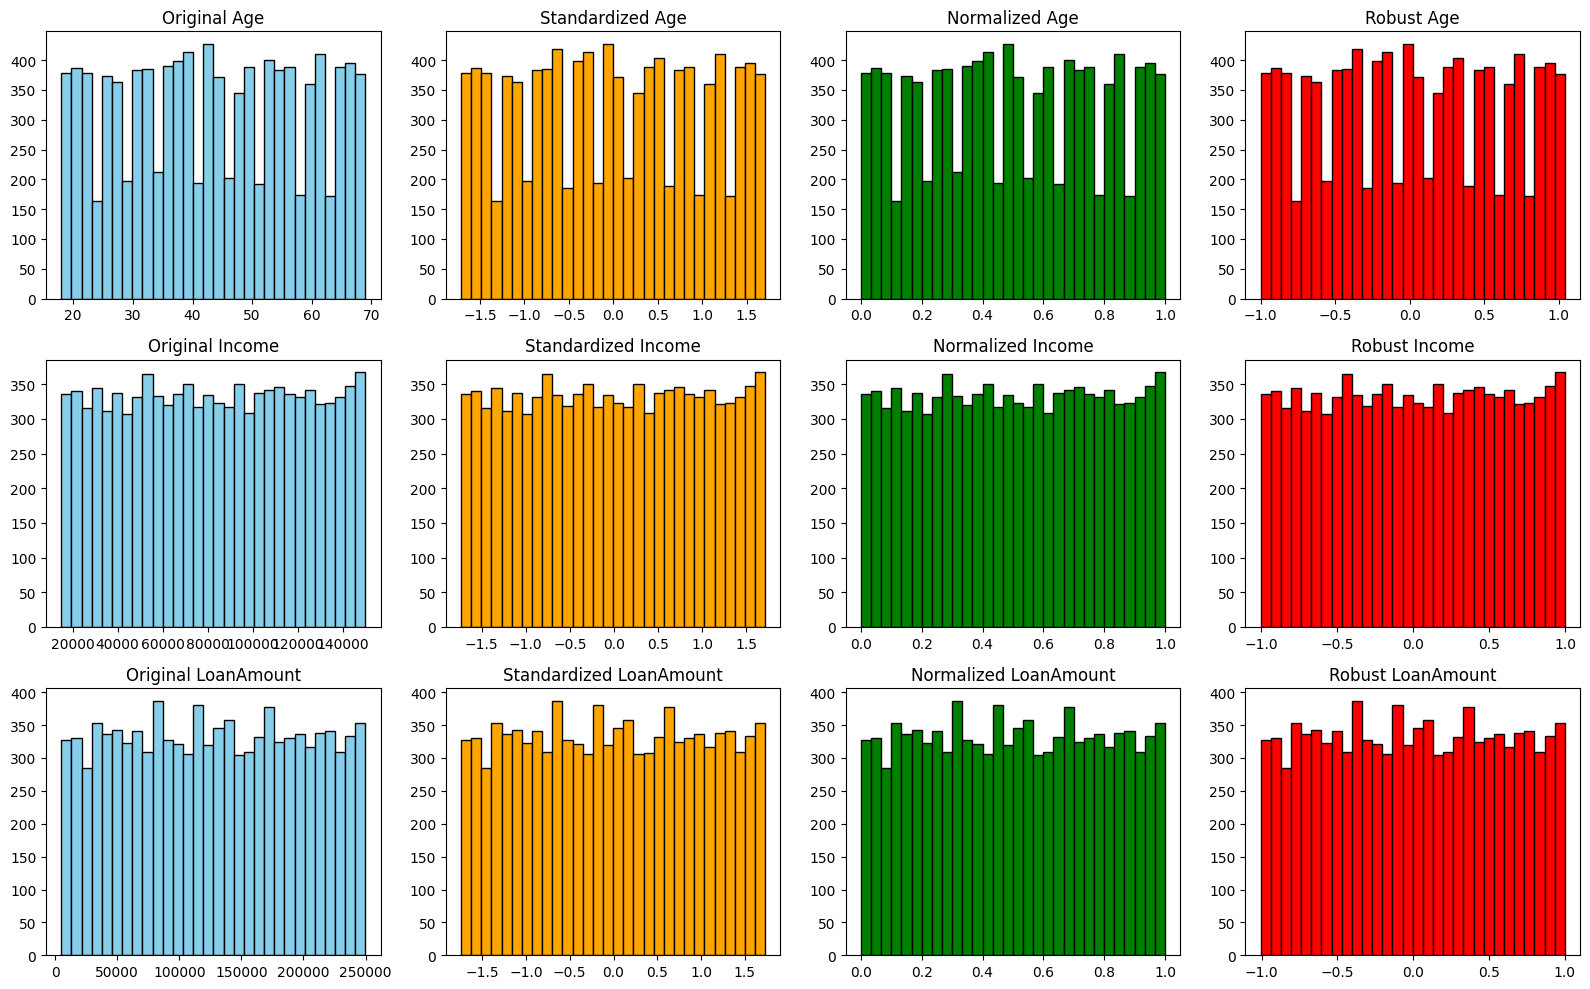

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# --- Load dataset (already uploaded) ---
df = pd.read_csv("Loan_default.csv", nrows=10000)

# Select only numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# --- Apply different scalers ---
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()
scaler_robust = RobustScaler()

df_std = pd.DataFrame(scaler_std.fit_transform(df[num_cols]), columns=num_cols)
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df[num_cols]), columns=num_cols)
df_robust = pd.DataFrame(scaler_robust.fit_transform(df[num_cols]), columns=num_cols)

# --- Visualization for comparison ---
cols_to_plot = ["Age", "Income", "LoanAmount"]  # choose important numeric features

fig, axes = plt.subplots(len(cols_to_plot), 4, figsize=(16, 10))

for i, col in enumerate(cols_to_plot):
    # Original
    axes[i,0].hist(df[col], bins=30, color="skyblue", edgecolor="black")
    axes[i,0].set_title(f"Original {col}")

    # Standardized
    axes[i,1].hist(df_std[col], bins=30, color="orange", edgecolor="black")
    axes[i,1].set_title(f"Standardized {col}")

    # Normalized
    axes[i,2].hist(df_minmax[col], bins=30, color="green", edgecolor="black")
    axes[i,2].set_title(f"Normalized {col}")

    # Robust
    axes[i,3].hist(df_robust[col], bins=30, color="red", edgecolor="black")
    axes[i,3].set_title(f"Robust {col}")

plt.tight_layout()
plt.show()


#5)Data Splitting

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
# Select features (X) and target (y)
# Assuming target column is "Default" (1 = default, 0 = no default) → change name if different
X = df.drop("Default", axis=1)
y = df["Default"]

# Split into train (70%), test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("✅ Data Splitting Completed!")
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


✅ Data Splitting Completed!
Training set shape: (7000, 17)
Testing set shape: (3000, 17)


#6)Data Reduction

In [6]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Load encoded dataset (from earlier step) ---
df = pd.read_csv("Loan_default.csv", nrows=100)

# One-hot encode categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Separate features and target
X = df_encoded.drop("Default", axis=1)
y = df_encoded["Default"]

# --- Standardize before PCA (important!) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Load encoded dataset (from earlier step) ---
df = pd.read_csv("Loan_default.csv", nrows=100)

# One-hot encode categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Separate features and target
X = df_encoded.drop("Default", axis=1)
y = df_encoded["Default"]

# --- Standardize before PCA (important!) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Apply PCA with explained variance threshold ---
pca = PCA(n_components=0.95)  # keep enough components to retain 95% variance
X_reduced = pca.fit_transform(X_scaled)

print("✅ Data Reduction with PCA Completed!")
print("Original shape:", X.shape)
print("Reduced shape :", X_reduced.shape)

# Explained variance
explained_var = pca.explained_variance_ratio_.sum()
print(f"Variance retained: {explained_var:.2%}")


✅ Data Reduction with PCA Completed!
Original shape: (100, 123)
Reduced shape : (100, 93)
Variance retained: 95.78%
